1.DATA LOADING & CONNECTION

In [ ]:
import pyodbc
import pandas as pd

# 1. الاتصال بالداتابيز
conn = pyodbc.connect('DRIVER={ODBC Driver 17 for SQL Server};'
                      r'SERVER=DESKTOP-9LMSTCP\SQLEXPRESS;'
                      'DATABASE=renewable energy;'
                      'Trusted_Connection=yes;')

# 2. قراءة البيانات فوراً
df = pd.read_sql("SELECT * FROM renewable_energy", conn)

# 3. قفل الاتصال
#conn.close()

# عرض أول 5 صفوف
df.head()

C:\Users\original store\AppData\Local\Temp\ipykernel_7136\1845418061.py:11: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql("SELECT * FROM renewable_energy", conn)


,Country,Year,Energy_Type,Production_GWh,Installed_Capacity_MW,Investments_USD,Population,GDP,Energy_Consumption,Energy_Exports,...,Economic_Freedom_Index,Ease_of_Doing_Business,Innovation_Index,Number_of_Research_Institutions,Number_of_Renewable_Energy_Conferences,Number_of_Renewable_Energy_Publications,Energy_Sector_Workforce,Proportion_of_Energy_from_Renewables,Public_Private_Partnerships_in_Energy,Regional_Renewable_Energy_Cooperation
0,USA,2011.0,Solar,85404.687500,5549.794434,5.604125e+09,1064007213,1.775280e+14,369654.65625,93087.195312,...,49.216801,57.678604,76.803230,851.0,75.0,6361,511658,25.907894,True,False
1,Australia,2008.0,Geothermal,22205.070312,43211.593750,6.361886e+08,1033255852,6.435370e+13,771781.62500,1752.536011,...,79.990944,1.761579,48.697826,590.0,39.0,9752,974948,95.003548,False,True
2,Canada,2013.0,Biomass,94102.734375,NaN,6.158680e+09,14895124,1.567930e+14,342707.15625,65146.593750,...,94.374039,77.657333,67.334816,101.0,7.0,311,326318,67.354538,True,False
3,Japan,2010.0,Biomass,88771.929688,40323.640625,8.526116e+09,1448827283,1.350460e+14,498839.56250,50257.589844,...,65.143471,44.987736,4.544289,NaN,3.0,7708,506078,33.754105,False,False
4,China,2018.0,Solar,93288.406250,30755.402344,5.086237e+09,1499494307,8.677960e+13,819064.37500,NaN,...,86.213623,62.535221,10.287199,985.0,69.0,4919,187964,59.509228,True,False


2.EXPLORATORY DATA ANALYSIS(EDA)

In [49]:
df.shape

(2500, 56)

In [50]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2500 entries, 0 to 2499
Data columns (total 56 columns):
 #   Column                                   Non-Null Count  Dtype  
---  ------                                   --------------  -----  
 0   Country                                  2500 non-null   object 
 1   Year                                     2499 non-null   float64
 2   Energy_Type                              2500 non-null   object 
 3   Production_GWh                           2446 non-null   float64
 4   Installed_Capacity_MW                    2440 non-null   float64
 5   Investments_USD                          2500 non-null   float64
 6   Population                               2500 non-null   int64  
 7   GDP                                      2500 non-null   float64
 8   Energy_Consumption                       2497 non-null   float64
 9   Energy_Exports                           2443 non-null   float64
 10  Energy_Imports                           2500 no

In [51]:
df.describe()



,Year,Production_GWh,Installed_Capacity_MW,Investments_USD,Population,GDP,Energy_Consumption,Energy_Exports,Energy_Imports,CO2_Emissions,...,Rule_of_Law,Control_of_Corruption,Economic_Freedom_Index,Ease_of_Doing_Business,Innovation_Index,Number_of_Research_Institutions,Number_of_Renewable_Energy_Conferences,Number_of_Renewable_Energy_Publications,Energy_Sector_Workforce,Proportion_of_Energy_from_Renewables
count,2499.000000,2446.000000,2440.000000,2.500000e+03,2.500000e+03,2.500000e+03,2497.000000,2443.000000,2500.000000,2500.000000,...,2500.000000,2499.000000,2499.000000,2500.000000,2500.000000,2490.000000,2494.000000,2500.00000,2500.000000,2500.000000
mean,2011.434574,48712.192521,24856.714593,4.956155e+09,7.458927e+08,1.010745e+14,495549.557232,50043.410653,50800.373861,491218.412738,...,5.048035,5.073425,50.756280,48.442085,50.280019,496.818876,50.431034,4978.93360,502040.891200,49.749110
std,6.895191,28371.427136,14462.180717,2.894789e+09,4.373146e+08,5.782363e+13,291406.718894,28828.451675,28740.851772,289783.733317,...,2.892496,2.906645,28.612778,28.798216,28.719483,296.445470,28.890651,2881.93256,293084.636148,28.924307
min,2000.000000,1053.354126,114.531639,5.886994e+06,1.255357e+06,5.603965e+10,1264.851074,1036.618042,1057.783569,1124.768433,...,0.003241,0.000973,0.104915,0.025281,0.025733,0.000000,0.000000,3.00000,494.000000,0.033829
25%,2006.000000,24225.080566,12246.140869,2.473145e+09,3.720811e+08,5.049265e+13,237529.812500,24908.998047,26347.461914,242894.718750,...,2.534236,2.613942,26.272232,23.519814,25.934406,234.000000,26.000000,2532.00000,244438.000000,23.968451
50%,2011.000000,47367.117188,24673.529297,4.961773e+09,7.515190e+08,1.027010e+14,495799.281250,49539.746094,50698.800781,475721.000000,...,5.034493,5.093903,50.858780,48.127672,51.398964,493.500000,51.000000,4992.50000,499151.000000,50.232069
75%,2017.000000,72952.916016,37440.907227,7.418384e+09,1.118019e+09,1.519602e+14,752931.062500,75544.937500,75807.642578,747649.437500,...,7.619311,7.693550,74.914108,73.324823,74.724075,755.000000,76.000000,7465.00000,765088.000000,74.354780
max,2023.000000,99937.500000,49997.386719,9.998292e+09,1.499494e+09,1.999220e+14,999618.500000,99952.507812,99912.210938,999816.500000,...,9.999630,9.998930,99.970528,99.901344,99.998840,999.000000,99.000000,9999.00000,999226.000000,99.988358


In [52]:
df.isnull().sum()


Country                                     0
Year                                        1
Energy_Type                                 0
Production_GWh                             54
Installed_Capacity_MW                      60
Investments_USD                             0
Population                                  0
GDP                                         0
Energy_Consumption                          3
Energy_Exports                             57
Energy_Imports                              0
CO2_Emissions                               0
Renewable_Energy_Jobs                      45
Government_Policies                         0
R_D_Expenditure                             0
Renewable_Energy_Targets                    0
Average_Annual_Temperature                 26
Annual_Rainfall                             1
Solar_Irradiance                           13
Wind_Speed                                  0
Hydro_Potential                             0
Geothermal_Potential              

In [ ]:
missing = df.isnull().sum()
missing[missing > 0]

Year                                       1
Production_GWh                            54
Installed_Capacity_MW                     60
Energy_Consumption                         3
Energy_Exports                            57
Renewable_Energy_Jobs                     45
Average_Annual_Temperature                26
Annual_Rainfall                            1
Solar_Irradiance                          13
Grid_Integration_Capability                1
Urbanization_Rate                          3
Renewable_Energy_Patents                   1
Local_Manufacturing_Capacity              10
Import_Tariffs_on_Energy_Equipment         2
Export_Incentives_for_Energy_Equipment     4
Corruption_Perception_Index                1
Control_of_Corruption                      1
Economic_Freedom_Index                     1
Number_of_Research_Institutions           10
Number_of_Renewable_Energy_Conferences     6
dtype: int64

3.DATA CLEANING

In [54]:
cols = [
    'Year',
    'Production_GWh',
    'Installed_Capacity_MW',
    'Energy_Consumption',
    'Energy_Exports',
    'Renewable_Energy_Jobs',
    'Average_Annual_Temperature',
    'Annual_Rainfall',
    'Solar_Irradiance',
    'Grid_Integration_Capability',
    'Urbanization_Rate',
    'Local_Manufacturing_Capacity',
    'Corruption_Perception_Index',
    'Control_of_Corruption',
    'Economic_Freedom_Index',
    'Number_of_Research_Institutions',
    'Renewable_Energy_Patents',
    'Import_Tariffs_on_Energy_Equipment',
    'Export_Incentives_for_Energy_Equipment',
    'Number_of_Renewable_Energy_Conferences'
    
]


In [55]:
for col in cols:
    df[col].fillna(df[col].mean(), inplace=True)




    

In [56]:
df.isnull().sum()

Country                                    0
Year                                       0
Energy_Type                                0
Production_GWh                             0
Installed_Capacity_MW                      0
Investments_USD                            0
Population                                 0
GDP                                        0
Energy_Consumption                         0
Energy_Exports                             0
Energy_Imports                             0
CO2_Emissions                              0
Renewable_Energy_Jobs                      0
Government_Policies                        0
R_D_Expenditure                            0
Renewable_Energy_Targets                   0
Average_Annual_Temperature                 0
Annual_Rainfall                            0
Solar_Irradiance                           0
Wind_Speed                                 0
Hydro_Potential                            0
Geothermal_Potential                       0
Biomass_Av

In [57]:
df.isnull().sum().sum()

0

In [58]:
cols_int = [
    'Year',
    'Renewable_Energy_Jobs',
    'Renewable_Energy_Patents',
    'Number_of_Research_Institutions',
    'Number_of_Renewable_Energy_Conferences',
    'Number_of_Renewable_Energy_Publications',
    'Energy_Sector_Workforce'
]

In [59]:
df[cols_int] = df[cols_int].round().astype(int)


In [60]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2500 entries, 0 to 2499
Data columns (total 56 columns):
 #   Column                                   Non-Null Count  Dtype  
---  ------                                   --------------  -----  
 0   Country                                  2500 non-null   object 
 1   Year                                     2500 non-null   int32  
 2   Energy_Type                              2500 non-null   object 
 3   Production_GWh                           2500 non-null   float64
 4   Installed_Capacity_MW                    2500 non-null   float64
 5   Investments_USD                          2500 non-null   float64
 6   Population                               2500 non-null   int64  
 7   GDP                                      2500 non-null   float64
 8   Energy_Consumption                       2500 non-null   float64
 9   Energy_Exports                           2500 non-null   float64
 10  Energy_Imports                           2500 no

In [61]:
df.duplicated().sum()

0

4.FEATURE ENGINEERING

In [62]:
df['Production_Per_Capita'] = df['Production_GWh'] / df['Population']

In [63]:
df['CO2_Per_Capita'] = df['CO2_Emissions'] / df['Population']

In [64]:
df['Export_Ratio'] = df['Energy_Exports'] / df['Production_GWh']

In [65]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2500 entries, 0 to 2499
Data columns (total 59 columns):
 #   Column                                   Non-Null Count  Dtype  
---  ------                                   --------------  -----  
 0   Country                                  2500 non-null   object 
 1   Year                                     2500 non-null   int32  
 2   Energy_Type                              2500 non-null   object 
 3   Production_GWh                           2500 non-null   float64
 4   Installed_Capacity_MW                    2500 non-null   float64
 5   Investments_USD                          2500 non-null   float64
 6   Population                               2500 non-null   int64  
 7   GDP                                      2500 non-null   float64
 8   Energy_Consumption                       2500 non-null   float64
 9   Energy_Exports                           2500 non-null   float64
 10  Energy_Imports                           2500 no

5.VISUALIZATION

In [66]:

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

# Professional Color Palette
colors = [
    "#0F4C81",   # Navy Blue
    "#00A6A6",   # Teal
    "#7AC943",   # Green
    "#FFC857",   # Gold
    "#FF6B6B",   # Coral
    "#6C5CE7",   # Purple
    "#2D3436"    # Dark Gray
]

C:\Users\original store\AppData\Local\Temp\ipykernel_7136\901443071.py:14: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df1 = pd.read_sql(query, conn)


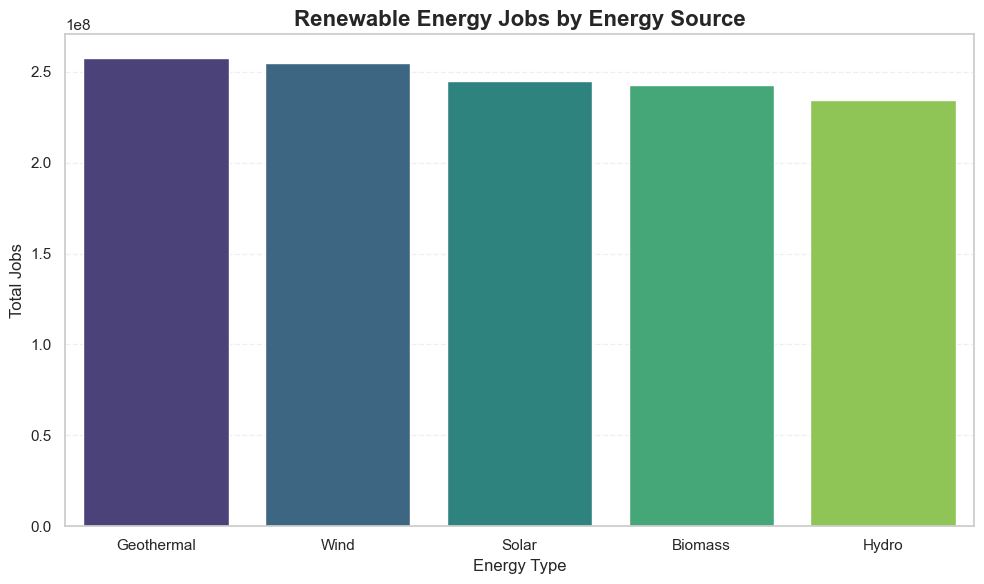

In [67]:

# Question 1:
# Which renewable energy source creates the highest employment opportunities?
# ما هو مصدر الطاقة المتجددة الذي يوفر أكبر عدد من فرص العمل؟

query = """
SELECT
    Energy_Type,
    SUM(Renewable_Energy_Jobs) AS Total_Jobs
FROM renewable_energy
GROUP BY Energy_Type
ORDER BY Total_Jobs DESC;
"""

df1 = pd.read_sql(query, conn)

plt.figure(figsize=(10,6))

sns.barplot(
    data=df1,
    x="Energy_Type",
    y="Total_Jobs",
    palette="viridis"
)

plt.title("Renewable Energy Jobs by Energy Source",
          fontsize=16,
          fontweight="bold")

plt.xlabel("Energy Type", fontsize=12)
plt.ylabel("Total Jobs", fontsize=12)

plt.xticks(fontsize=11)
plt.yticks(fontsize=11)

plt.grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

C:\Users\original store\AppData\Local\Temp\ipykernel_7136\4002134578.py:14: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df2 = pd.read_sql(query, conn)


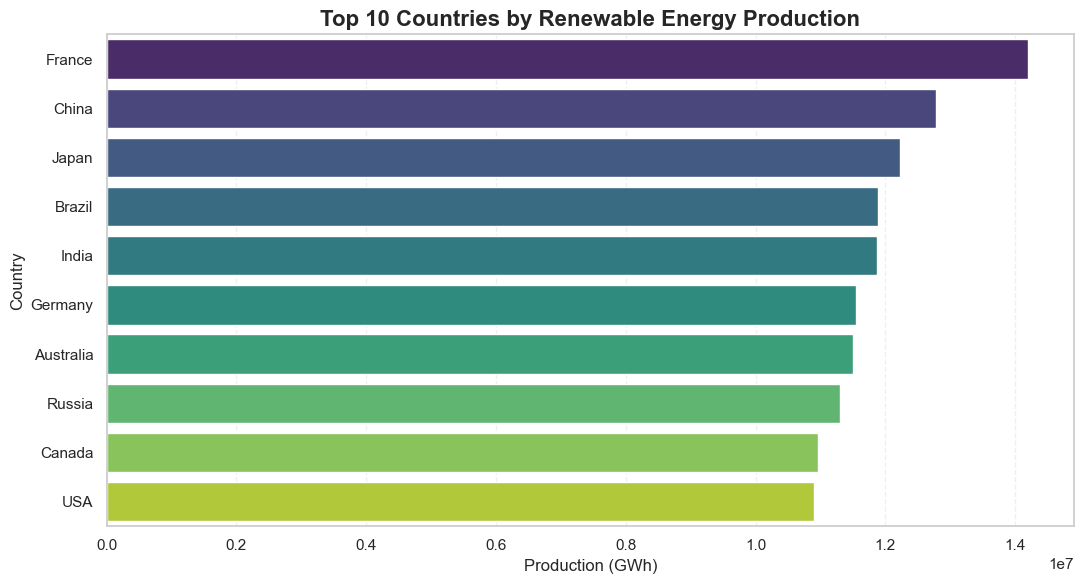

In [68]:
# Question2:
# Which countries produce the highest amount of renewable energy?
# ما هي الدول التي تنتج أكبر كمية من الطاقة المتجددة؟

query = """
SELECT TOP 10
    Country,
    SUM(Production_GWh) AS Total_Production
FROM renewable_energy
GROUP BY Country
ORDER BY Total_Production DESC;
"""

df2 = pd.read_sql(query, conn)

plt.figure(figsize=(11,6))

sns.barplot(
    data=df2,
    x="Total_Production",
    y="Country",
    palette="viridis"
)

plt.title(
    "Top 10 Countries by Renewable Energy Production",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Production (GWh)", fontsize=12)
plt.ylabel("Country", fontsize=12)

plt.grid(axis="x", linestyle="--", alpha=0.3)

plt.tight_layout()

plt.show()

C:\Users\original store\AppData\Local\Temp\ipykernel_7136\1879153662.py:15: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df3 = pd.read_sql(query, conn)


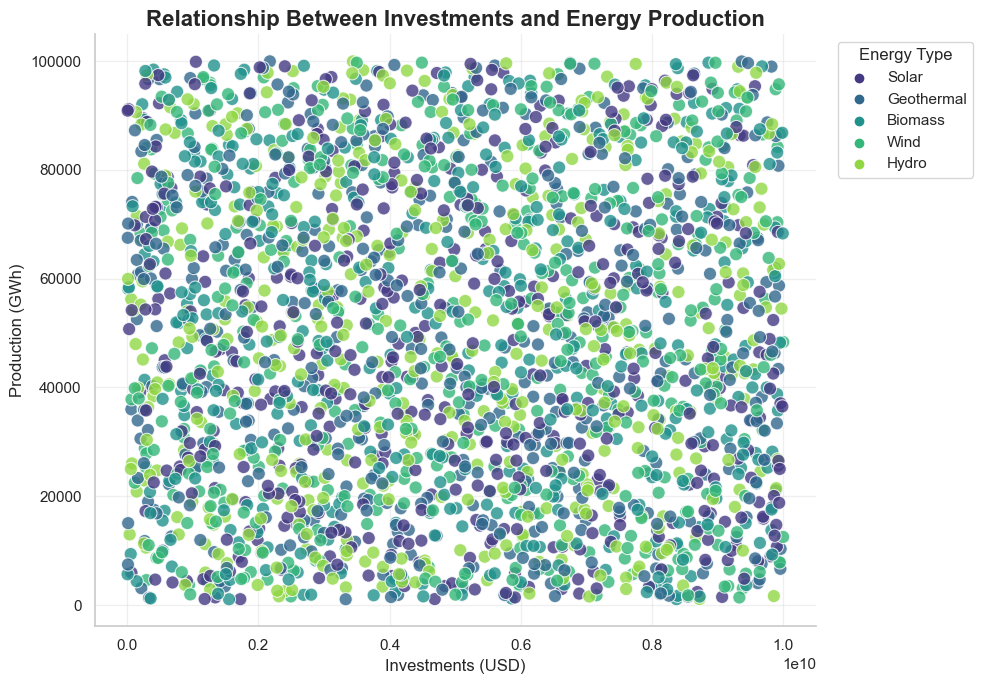

In [ ]:

# Figure 3
# Question:
# Is there a relationship between investments and renewable energy production?
# هل توجد علاقة بين الاستثمارات وإنتاج الطاقة المتجددة؟


query = """
SELECT
    Investments_USD,
    Production_GWh,
    Energy_Type
FROM renewable_energy;
"""

df3 = pd.read_sql(query, conn)

plt.figure(figsize=(10,7))

sns.scatterplot(
    data=df3,
    x="Investments_USD",
    y="Production_GWh",
    hue="Energy_Type",
    palette="viridis",
    s=90,
    alpha=0.8
)

plt.title(
    "Relationship Between Investments and Energy Production",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Investments (USD)", fontsize=12)
plt.ylabel("Production (GWh)", fontsize=12)

plt.legend(title="Energy Type", bbox_to_anchor=(1.02,1), loc="upper left")

plt.grid(alpha=0.3)

sns.despine()

plt.tight_layout()

plt.show()






C:\Users\original store\AppData\Local\Temp\ipykernel_7136\3367496620.py:15: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df4 = pd.read_sql(query, conn)
c:\Users\original store\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\original store\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


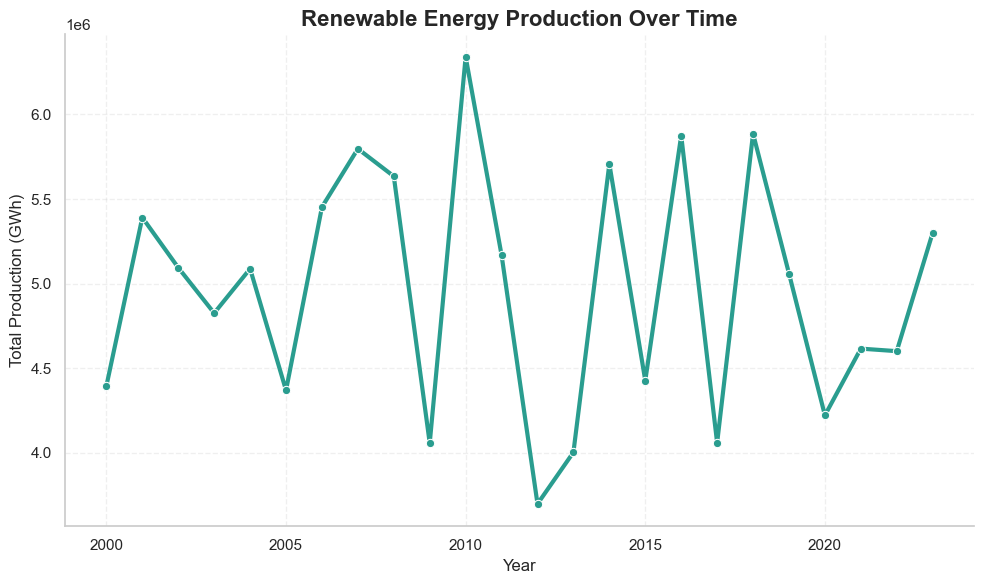

In [70]:

# Question4:
# How has renewable energy production changed over the years?
# كيف تغير إنتاج الطاقة المتجددة على مدار السنوات؟


query = """
SELECT
    Year,
    SUM(Production_GWh) AS Total_Production
FROM renewable_energy
GROUP BY Year
ORDER BY Year;
"""

df4 = pd.read_sql(query, conn)

plt.figure(figsize=(10,6))

sns.lineplot(
    data=df4,
    x="Year",
    y="Total_Production",
    marker="o",
    linewidth=3,
    color="#2A9D8F"
)

plt.title(
    "Renewable Energy Production Over Time",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Year", fontsize=12)
plt.ylabel("Total Production (GWh)", fontsize=12)

plt.grid(alpha=0.3, linestyle="--")

sns.despine()

plt.tight_layout()

plt.show()


C:\Users\original store\AppData\Local\Temp\ipykernel_7136\1566913474.py:18: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df5 = pd.read_sql(query, conn)


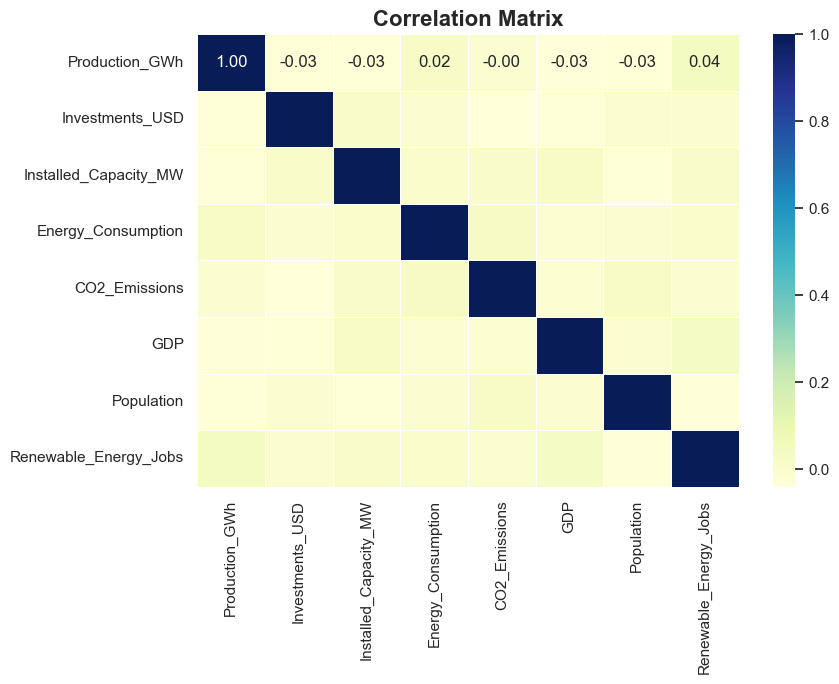

In [ ]:

# Question 5:
# Which variables have the strongest correlation with renewable energy production?
# ما هي المتغيرات الأكثر ارتباطًا بإنتاج الطاقة المتجددة؟

query = """
SELECT
    Production_GWh,
    Investments_USD,
    Installed_Capacity_MW,
    Energy_Consumption,
    CO2_Emissions,
    GDP,
    Population,
    Renewable_Energy_Jobs
FROM renewable_energy;
"""

df5 = pd.read_sql(query, conn)

corr = df5.corr(numeric_only=True)

plt.figure(figsize=(9,7))

sns.heatmap(
    corr,
    annot=True,
    cmap="YlGnBu",
    fmt=".2f",
    linewidths=0.5
)

plt.title(
    "Correlation Matrix",
    fontsize=16,
    fontweight="bold"
)

plt.tight_layout()

plt.show()

C:\Users\original store\AppData\Local\Temp\ipykernel_7136\1918722131.py:13: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df6 = pd.read_sql(query, conn)


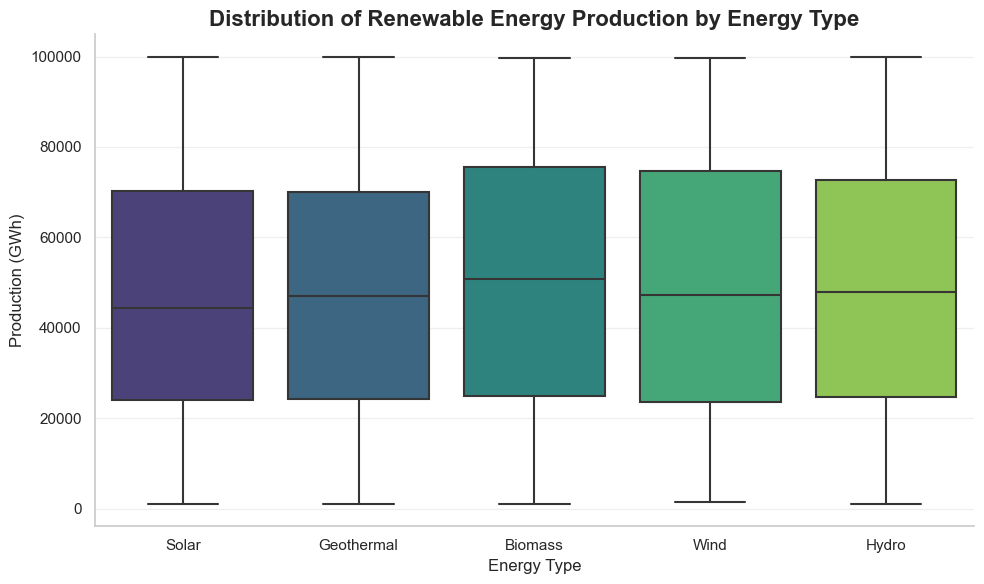

In [72]:

# Question6:
# How does renewable energy production vary across different energy types?
# كيف يختلف إنتاج الطاقة المتجددة بين أنواع الطاقة المختلفة؟


query = """
SELECT
    Energy_Type,
    Production_GWh
FROM renewable_energy;
"""

df6 = pd.read_sql(query, conn)

plt.figure(figsize=(10,6))

sns.boxplot(
    data=df6,
    x="Energy_Type",
    y="Production_GWh",
    palette="viridis"
)

plt.title(
    "Distribution of Renewable Energy Production by Energy Type",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Energy Type", fontsize=12)
plt.ylabel("Production (GWh)", fontsize=12)

plt.grid(axis="y", alpha=0.3)

sns.despine()

plt.tight_layout()

plt.show()

C:\Users\original store\AppData\Local\Temp\ipykernel_7136\1344695978.py:13: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df7 = pd.read_sql(query, conn)


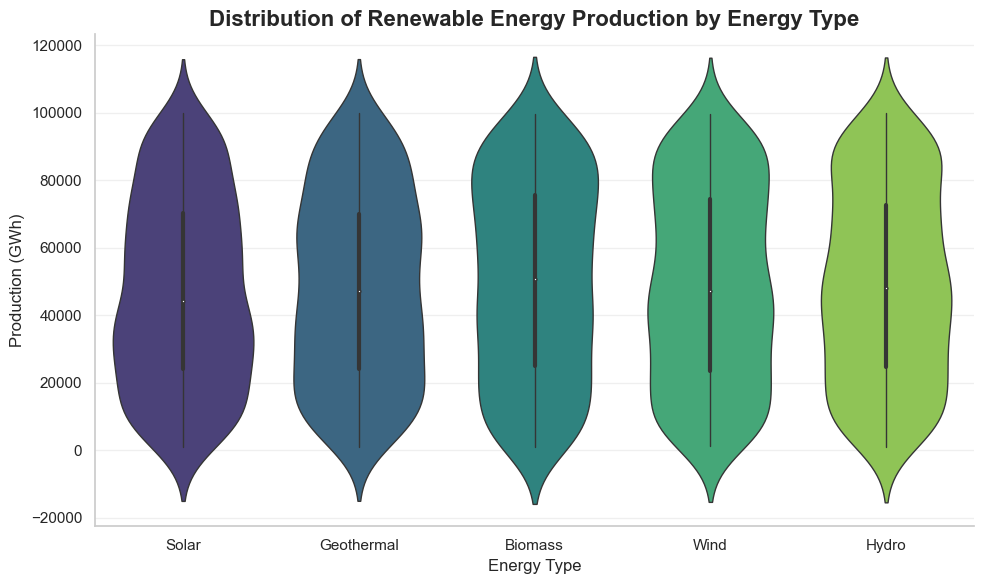

In [73]:

# Question7:
# How is renewable energy production distributed across different energy types?
# كيف يتوزع إنتاج الطاقة المتجددة بين أنواع الطاقة المختلفة؟


query = """
SELECT
    Energy_Type,
    Production_GWh
FROM renewable_energy;
"""

df7 = pd.read_sql(query, conn)

plt.figure(figsize=(10,6))

sns.violinplot(
    data=df7,
    x="Energy_Type",
    y="Production_GWh",
    palette="viridis",
    inner="box",
    linewidth=1
)

plt.title(
    "Distribution of Renewable Energy Production by Energy Type",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Energy Type", fontsize=12)
plt.ylabel("Production (GWh)", fontsize=12)

plt.grid(axis="y", alpha=0.3)

sns.despine()

plt.tight_layout()

plt.show()

6. MACHINE LEARNING

In [74]:
#1: select feature and target
X = df[[
    "Installed_Capacity_MW",
    "Investments_USD",
    "Population",
    "GDP",
    "Energy_Consumption",
    "Renewable_Energy_Jobs",
    "Solar_Irradiance",
    "Wind_Speed",
    "Hydro_Potential",
    "Energy_Storage_Capacity"
]]

y = df["Production_Per_Capita"]

In [75]:
#2:data partitioning
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [76]:
#3:import model
from sklearn.ensemble import RandomForestRegressor

In [77]:
#4:create model
model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

In [78]:
#5:model training
model.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [79]:
#6:model prediction
y_pred = model.predict(X_test)

In [80]:
#7:model evaluation
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Mean Absolute Error (MAE):", mae)
print("Mean Squared Error (MSE):", mse)
print("R² Score:", r2)

Mean Absolute Error (MAE): 0.0001038835899172606
Mean Squared Error (MSE): 3.42316513735398e-07
R² Score: 0.8513969829358038


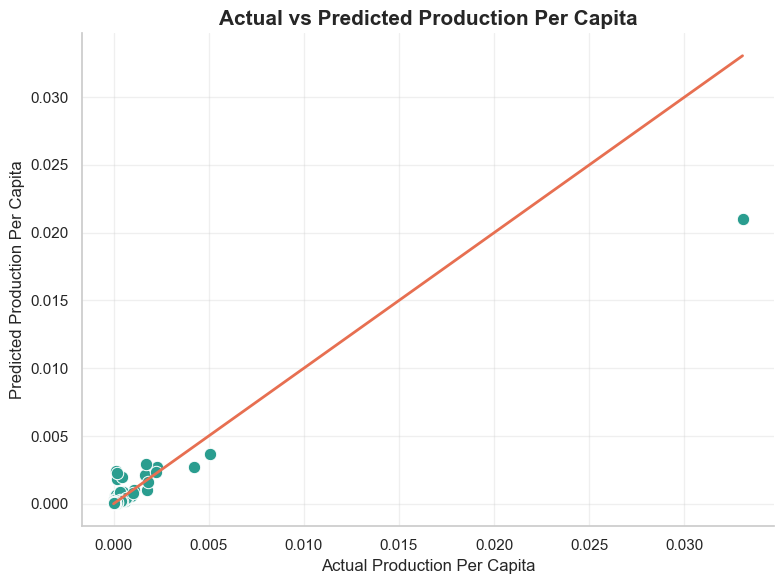

In [81]:
#8:actual vs predicted

plt.figure(figsize=(8,6))

sns.scatterplot(
    x=y_test,
    y=y_pred,
    color="#2A9D8F",
    s=80
)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color="#E76F51",
    linewidth=2
)

plt.title(
    "Actual vs Predicted Production Per Capita",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel("Actual Production Per Capita", fontsize=12)
plt.ylabel("Predicted Production Per Capita", fontsize=12)

plt.grid(alpha=0.3)

sns.despine()

plt.tight_layout()

plt.show()